# LeetCode #125: Valid Palindrome

https://leetcode.com/problems/valid-palindrome/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Filter + Reverse | O(n) | O(n) | Extra cleaned string |
| **Two Pointers (in-place)** | **O(n)** | **O(1)** | **Optimal — no extra space** |

## Understanding the Method

Use two pointers (left and right) converging inward:
- Skip non-alphanumeric characters on each side
- Compare lowercased characters
- If any mismatch, return false
- If pointers cross, return true

## Constraints

- `1 <= s.length <= 2 * 10^5`
- `s` consists only of printable ASCII characters

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsPalindrome(string s) {
        int l = 0, r = s.Length - 1;
        while (l < r) {
            while (l < r && !char.IsLetterOrDigit(s[l])) l++;
            while (l < r && !char.IsLetterOrDigit(s[r])) r--;
            if (char.ToLower(s[l]) != char.ToLower(s[r])) return false;
            l++; r--;
        }
        return true;
    }
}

### Python

In [ ]:
class Solution:
    def isPalindrome(self, s: str) -> bool:
        l, r = 0, len(s) - 1
        while l < r:
            while l < r and not s[l].isalnum():
                l += 1
            while l < r and not s[r].isalnum():
                r -= 1
            if s[l].lower() != s[r].lower():
                return False
            l += 1; r -= 1
        return True

### Go

In [ ]:
import "unicode"

func isPalindrome(s string) bool {
    l, r := 0, len(s)-1
    for l < r {
        for l < r && !unicode.IsLetter(rune(s[l])) && !unicode.IsDigit(rune(s[l])) { l++ }
        for l < r && !unicode.IsLetter(rune(s[r])) && !unicode.IsDigit(rune(s[r])) { r-- }
        if unicode.ToLower(rune(s[l])) != unicode.ToLower(rune(s[r])) {
            return false
        }
        l++; r--
    }
    return true
}

### Rust

In [ ]:
impl Solution {
    pub fn is_palindrome(s: String) -> bool {
        let chars: Vec<char> = s.chars().filter(|c| c.is_alphanumeric()).collect();
        let n = chars.len();
        (0..n/2).all(|i| chars[i].to_lowercase().eq(chars[n-1-i].to_lowercase()))
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `s = "A man, a plan, a canal: Panama"`  
Two pointers skip non-alphanumeric chars and compare case-insensitively. Cleaned: "amanaplanacanalpanama" -- reads the same forward and backward.  
WHY tricky: Must skip punctuation and spaces. Case-insensitive comparison ($A == a$). LaTeX: $s[l].\text{lower}() = s[r].\text{lower}()$.

### 2. Slightly Complex -- Digits Mixed with Letters
**Input:** `s = "0P"`  
Both chars are alphanumeric. `'0'` vs `'p'` (lowercased): `'0' != 'p'`. Not a palindrome. Digit zero and letter O are different characters.  
WHY tricky: `'0'` (digit) $\ne$ `'O'` (letter). `isAlphanumeric` includes digits. Common bug: confusing `'0'` with `'o'`. LaTeX: $\text{ord}('0') = 48 \ne \text{ord}('p') = 112$.

### 3. Edge Case: Time Factor
**Input:** `s` $= 200{,}000$ characters, all `'a'` with random punctuation between each  
Two pointers traverse from both ends. Each pointer visits each character at most once. Total: $O(n) = 200{,}000$ inspections. Inner skip loops don't add extra passes.  
WHY tricky: Skip loops might seem $O(n^2)$, but each char is visited at most once by each pointer -- amortized $O(n)$. LaTeX: $T(n) = O(n)$.

### 4. Edge Case: Space Factor
**Input:** `s` $= 200{,}000$ characters of mixed content  
Two-pointer uses $O(1)$ extra space: just two integer indices. Compare with filter+reverse: $O(n)$ for cleaned copy.  
WHY tricky: Naive approach allocates $O(n)$ for filtered string. Two-pointer does it in-place. LaTeX: $\text{space} = O(1)$ vs $O(n)$.

### 5. Almost-Impossible but Plausible
**Input:** `s` $= 200{,}000$ non-alphanumeric characters (`"!@#$%^&*()..."`)  
Both pointers skip everything. $L$ crosses $R$ without any comparison. Empty alphanumeric content is a palindrome by convention.  
WHY tricky: Edge case of empty effective content. All characters skipped, pointers cross. LaTeX: $l \ge r$ after all skips $\Rightarrow$ true (vacuously).

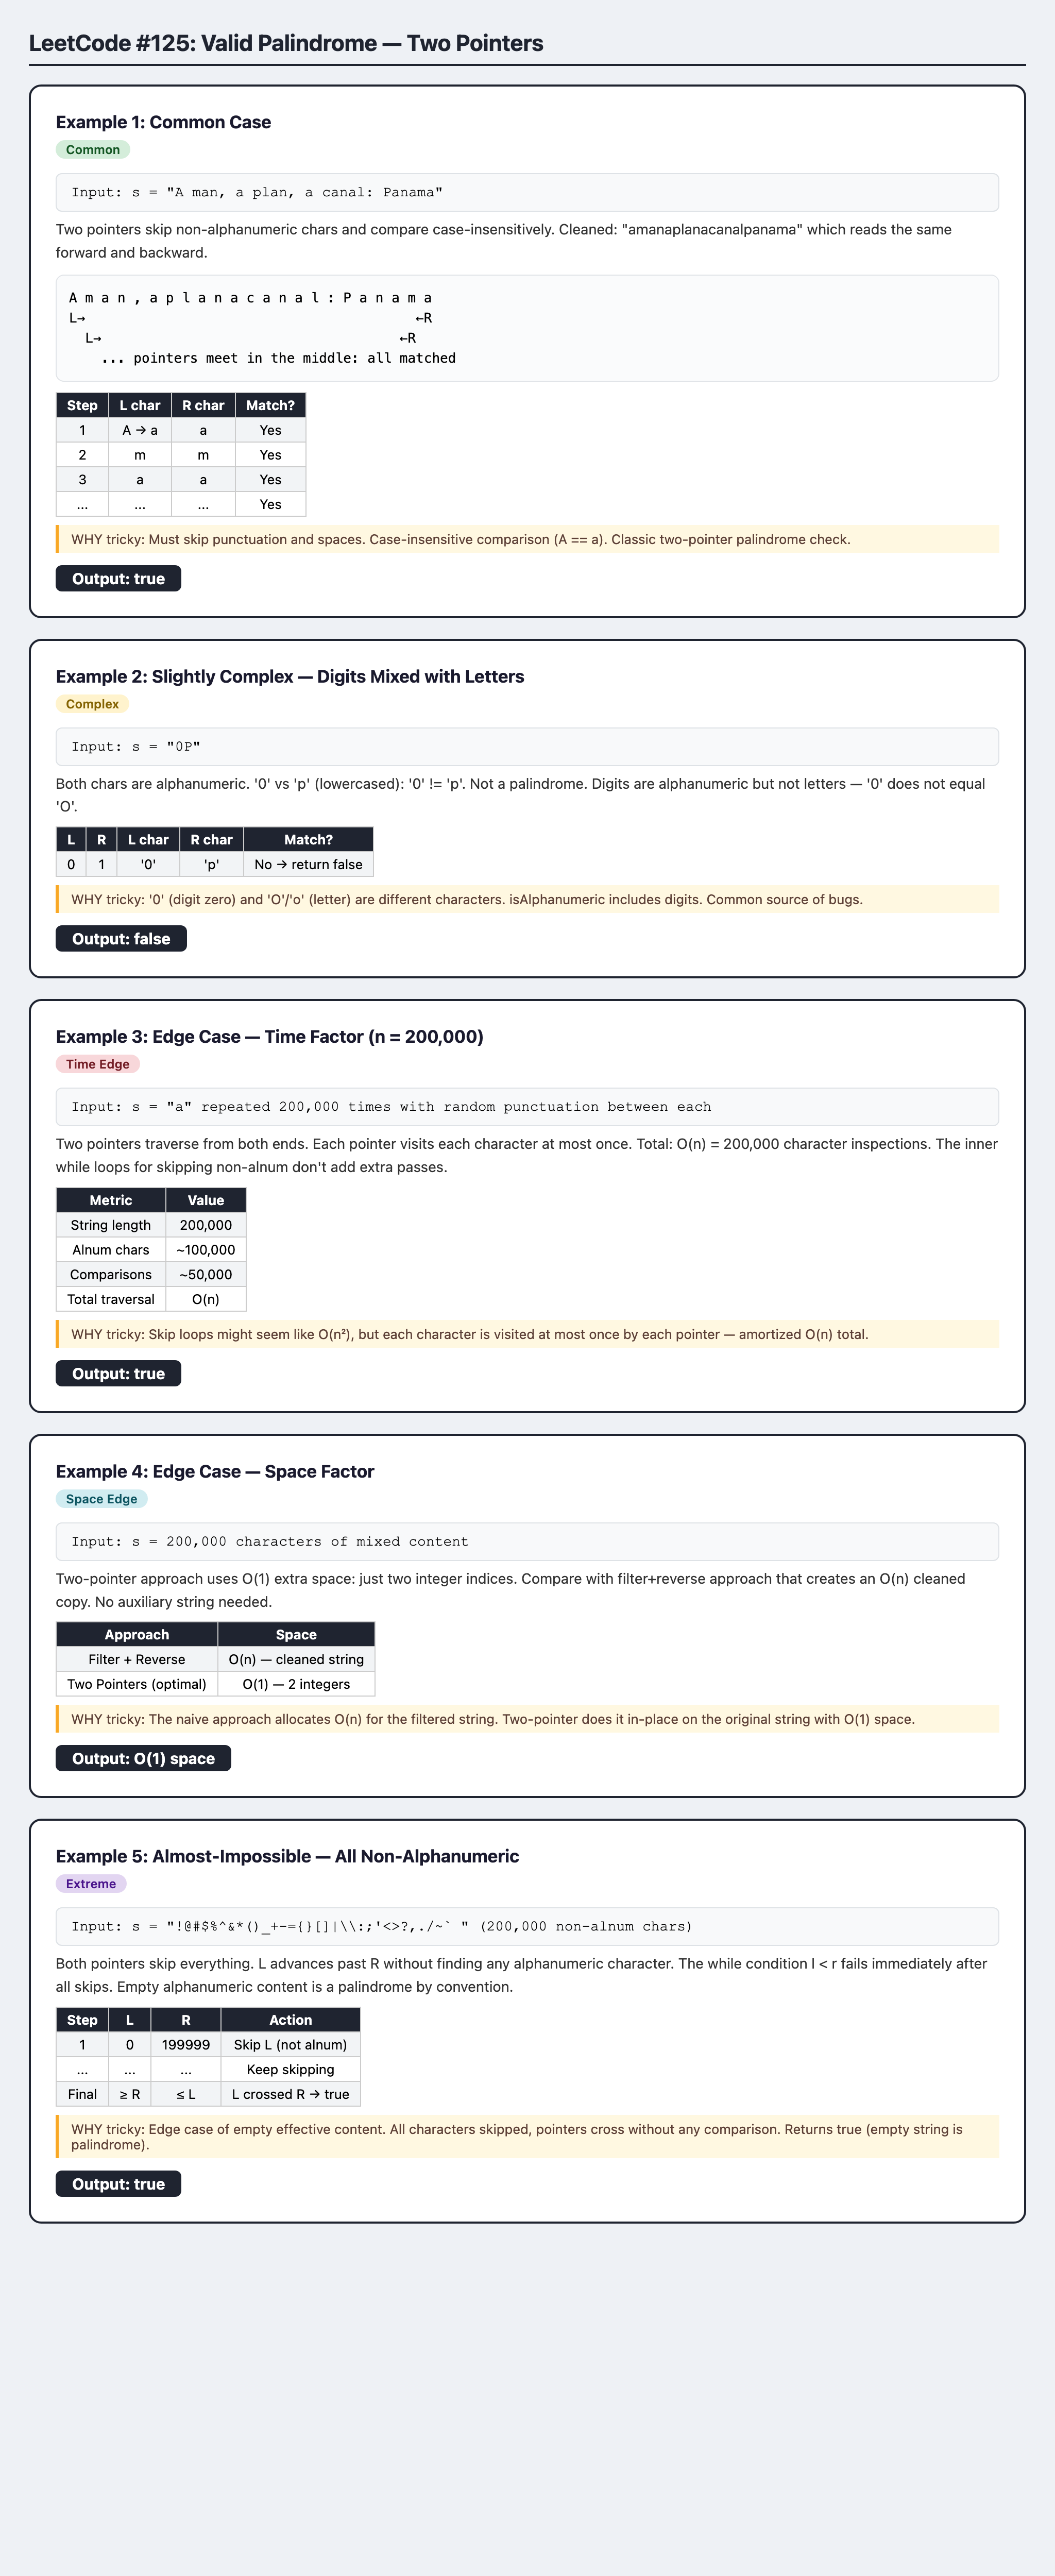